In [2]:
import matplotlib.pyplot as plt
import numpy as np
from optiland import analysis
from optiland.fileio import load_zemax_file

In [2]:


# Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

Simulating Spherical Lens...
Simulating Aspheric Lens...
Simulating Fiber Collimator...


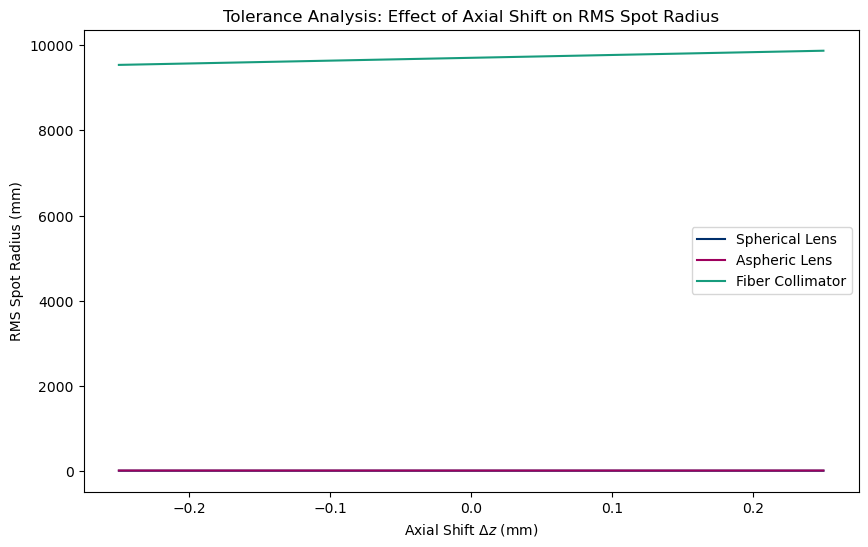

In [ ]:
def simuliere_toleranz(url, nominal_thickness, dz_array):
    """
    Lädt eine Linse, simuliert einen axialen Versatz und berechnet den RMS-Spot.
    """
    lens = load_zemax_file(url)
    rms_spot_radius = []
    
    # Indizes für zentrale Wellenlänge und On-Axis-Feld
    wavelength_idx = 0
    field_idx = 0
    
    for z in dz_array:
        # Ändere die Distanz am Anfang des Systems (simuliert den Piezo/Schlitten)
        lens.updater.set_thickness(value=nominal_thickness + z, surface_number=0)
        
        # Fokussiere das Bild neu (paraxialer Fokus)
        lens.image_solve() 
        
        # Berechne den RMS Spot Radius
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius

# === 1. URLs der Thorlabs .zmx Dateien ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 2. Simulations-Parameter einstellen ===
dz = np.linspace(-0.25, 0.25, 64)
start_distanz = 15.0 

# === 3. Simulation für alle drei Systeme durchführen ===
print("Simulating Spherical Lens...")
rms_sphaere = simuliere_toleranz(url_sphaere, start_distanz, dz)

print("Simulating Aspheric Lens...")
rms_asphaere = simuliere_toleranz(url_asphaere, start_distanz, dz)

print("Simulating Fiber Collimator...")
rms_kolli = simuliere_toleranz(url_kolli, start_distanz, dz)

# === 4. Ergebnisse plotten ===
plt.figure(figsize=(10, 6))

# Plot der drei Kurven mit wissenschaftlichem Farbschema und englischer Legende
plt.plot(dz, rms_sphaere, label="Spherical Lens", color="#002F6C")
plt.plot(dz, rms_asphaere, label="Aspheric Lens", color="#9E005D")
plt.plot(dz, rms_kolli, label="Fiber Collimator", color="#179C7D")

# Diagramm formatieren (Englisch)
plt.xlabel("Axial Shift $\Delta z$ (mm)")
plt.ylabel("RMS Spot Radius (mm)")
plt.title("Tolerance Analysis: Effect of Axial Shift on RMS Spot Radius")
plt.legend()

# Plot als druckfähiges PDF speichern
#plt.savefig(r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/ToleranceAnalysis_Axial.pdf")

# Plot im Notebook anzeigen
plt.show()

Simulating Spherical Lens...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/3578836532.py:12: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


Simulating Aspheric Lens...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/3578836532.py:12: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


Simulating Fiber Collimator...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/3578836532.py:12: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()


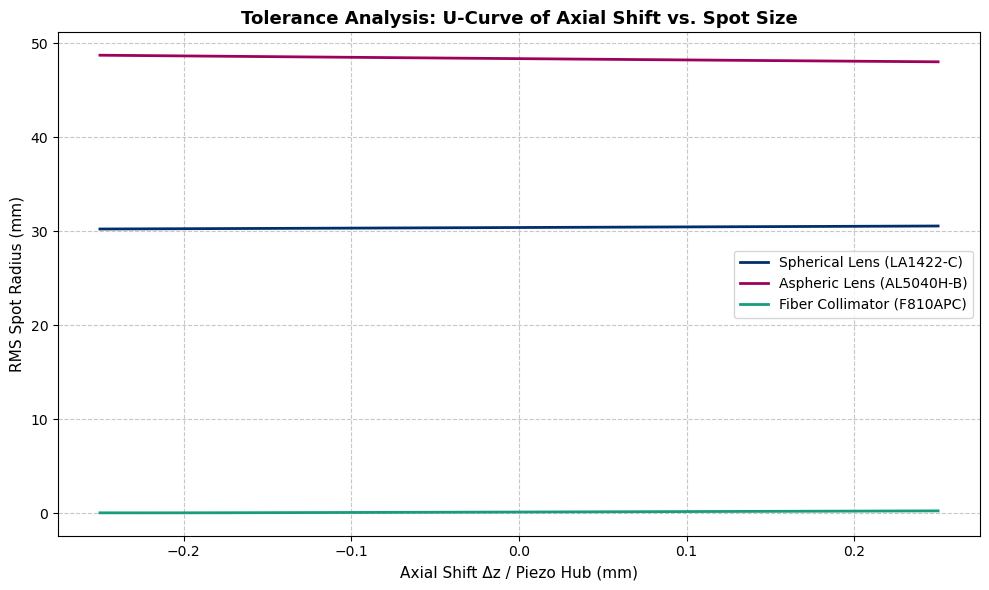

In [7]:
# einmal fokussieren ohne normierung etc

def simuliere_toleranz(url, nominal_thickness, dz_array):
    """
    Lädt eine Linse, kalibriert den Fokus einmalig und simuliert dann den Piezo-Hub.
    """
    lens = load_zemax_file(url)
    
    # === SCHRITT 1: Die optische Bank kalibrieren ===
    # Wir setzen die Faser auf die Startposition und fokussieren den Detektor einmalig perfekt
    lens.updater.set_thickness(value=nominal_thickness, surface_number=0)
    lens.image_solve() 
    
    rms_spot_radius = []
    wavelength_idx = 0
    field_idx = 0
    
    # === SCHRITT 2: Toleranzanalyse (Piezo fährt) ===
    for z in dz_array:
        # Piezo verschiebt die Faser um dz
        lens.updater.set_thickness(value=nominal_thickness + z, surface_number=0)
        
        # WICHTIG: Hier KEIN image_solve()! Der Sensor bleibt festgeschraubt.
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius

# === 2. Simulations-Parameter einstellen ===
dz = np.linspace(-0.25, 0.25, 64)

# Wir weisen jeder Linse ihren spezifischen Fokus-Abstand (in mm) zu
start_sphaere = 34.6   # Back Focal Length für LA1422-C
start_asphaere = 31.4  # Back Focal Length für AL5040H-B
start_kolli = 8.2      # Typischer Faserabstand im F810-Package

# === 3. Simulation für alle drei Systeme durchführen ===
print("Simulating Spherical Lens...")
rms_sphaere = simuliere_toleranz(url_sphaere, start_sphaere, dz)

print("Simulating Aspheric Lens...")
rms_asphaere = simuliere_toleranz(url_asphaere, start_asphaere, dz)

print("Simulating Fiber Collimator...")
rms_kolli = simuliere_toleranz(url_kolli, start_kolli, dz)

# === 4. Ergebnisse plotten (Absolute Werte, keine Normierung!) ===
plt.figure(figsize=(10, 6))

plt.plot(dz, rms_sphaere, label="Spherical Lens (LA1422-C)", color="#002F6C", linewidth=2)
plt.plot(dz, rms_asphaere, label="Aspheric Lens (AL5040H-B)", color="#9E005D", linewidth=2)
plt.plot(dz, rms_kolli, label="Fiber Collimator (F810APC)", color="#179C7D", linewidth=2)

plt.xlabel("Axial Shift Δz / Piezo Hub (mm)", fontsize=11)
plt.ylabel("RMS Spot Radius (mm)", fontsize=11)
plt.title("Tolerance Analysis: U-Curve of Axial Shift vs. Spot Size", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

Simulating Spherical Lens...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: Depre

Simulating Aspheric Lens...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: Depre

Simulating Fiber Collimator...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_22713/2365799884.py:17: Depre

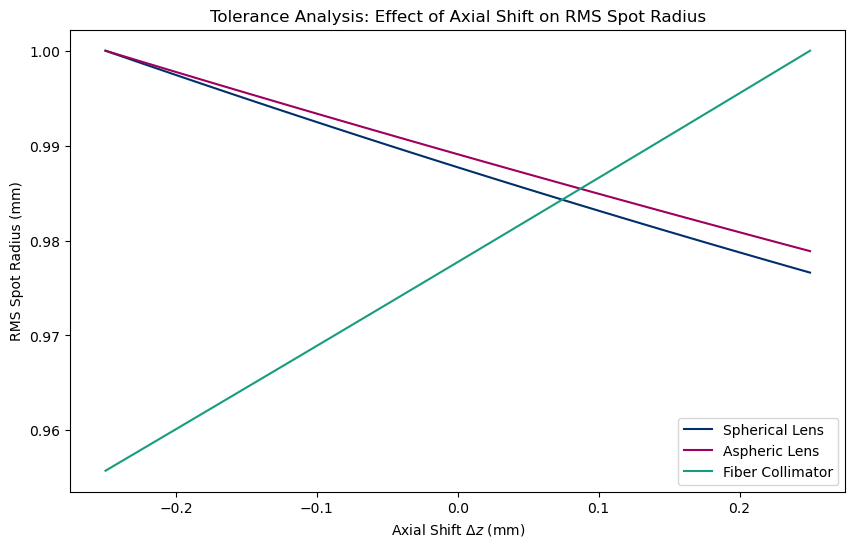

In [ ]:
def simuliere_toleranz(url, nominal_thickness, dz_array):
    """
    Lädt eine Linse, simuliert einen axialen Versatz und berechnet den RMS-Spot.
    """
    lens = load_zemax_file(url)
    rms_spot_radius = []
    
    # Indizes für zentrale Wellenlänge und On-Axis-Feld
    wavelength_idx = 0
    field_idx = 0
    
    for z in dz_array:
        # Ändere die Distanz am Anfang des Systems (simuliert den Piezo/Schlitten)
        lens.updater.set_thickness(value=nominal_thickness + z, surface_number=0)
        
        # Fokussiere das Bild neu (paraxialer Fokus)
        lens.image_solve()
        
        # Berechne den RMS Spot Radius
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius

# === 1. URLs der Thorlabs .zmx Dateien ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 2. Simulations-Parameter einstellen ===
dz = np.linspace(-0.25, 0.25, 64)
start_distanz = 15.0 

# === 3. Simulation für alle drei Systeme durchführen ===
print("Simulating Spherical Lens...")
rms_sphaere = simuliere_toleranz(url_sphaere, start_distanz, dz)

print("Simulating Aspheric Lens...")
rms_asphaere = simuliere_toleranz(url_asphaere, start_distanz, dz)

print("Simulating Fiber Collimator...")
rms_kolli = simuliere_toleranz(url_kolli, start_distanz, dz)

# === 4. Ergebnisse plotten ===
plt.figure(figsize=(10, 6))

# Plot der drei Kurven mit wissenschaftlichem Farbschema und englischer Legende
plt.plot(dz, rms_sphaere/np.max(rms_sphaere), label="Spherical Lens", color="#002F6C")
plt.plot(dz, rms_asphaere/np.max(rms_asphaere), label="Aspheric Lens", color="#9E005D")
plt.plot(dz, rms_kolli/np.max(rms_kolli), label="Fiber Collimator", color="#179C7D")

# Diagramm formatieren (Englisch)
plt.xlabel("Axial Shift $\Delta z$ (mm)")
plt.ylabel("RMS Spot Radius (mm)")
plt.title("Tolerance Analysis: Effect of Axial Shift on RMS Spot Radius, norminated at maximum value")
plt.legend()

# Plot als druckfähiges PDF speichern
#plt.savefig(r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/ToleranceAnalysis_Axial_normiert.pdf")

# Plot im Notebook anzeigen
plt.show()

Simulating lateral tolerance (Spherical Lens)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: Depre

Simulating lateral tolerance (Aspheric Lens)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: Depre

Simulating lateral tolerance (Fiber Collimator)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_17771/2158225696.py:21: Depre

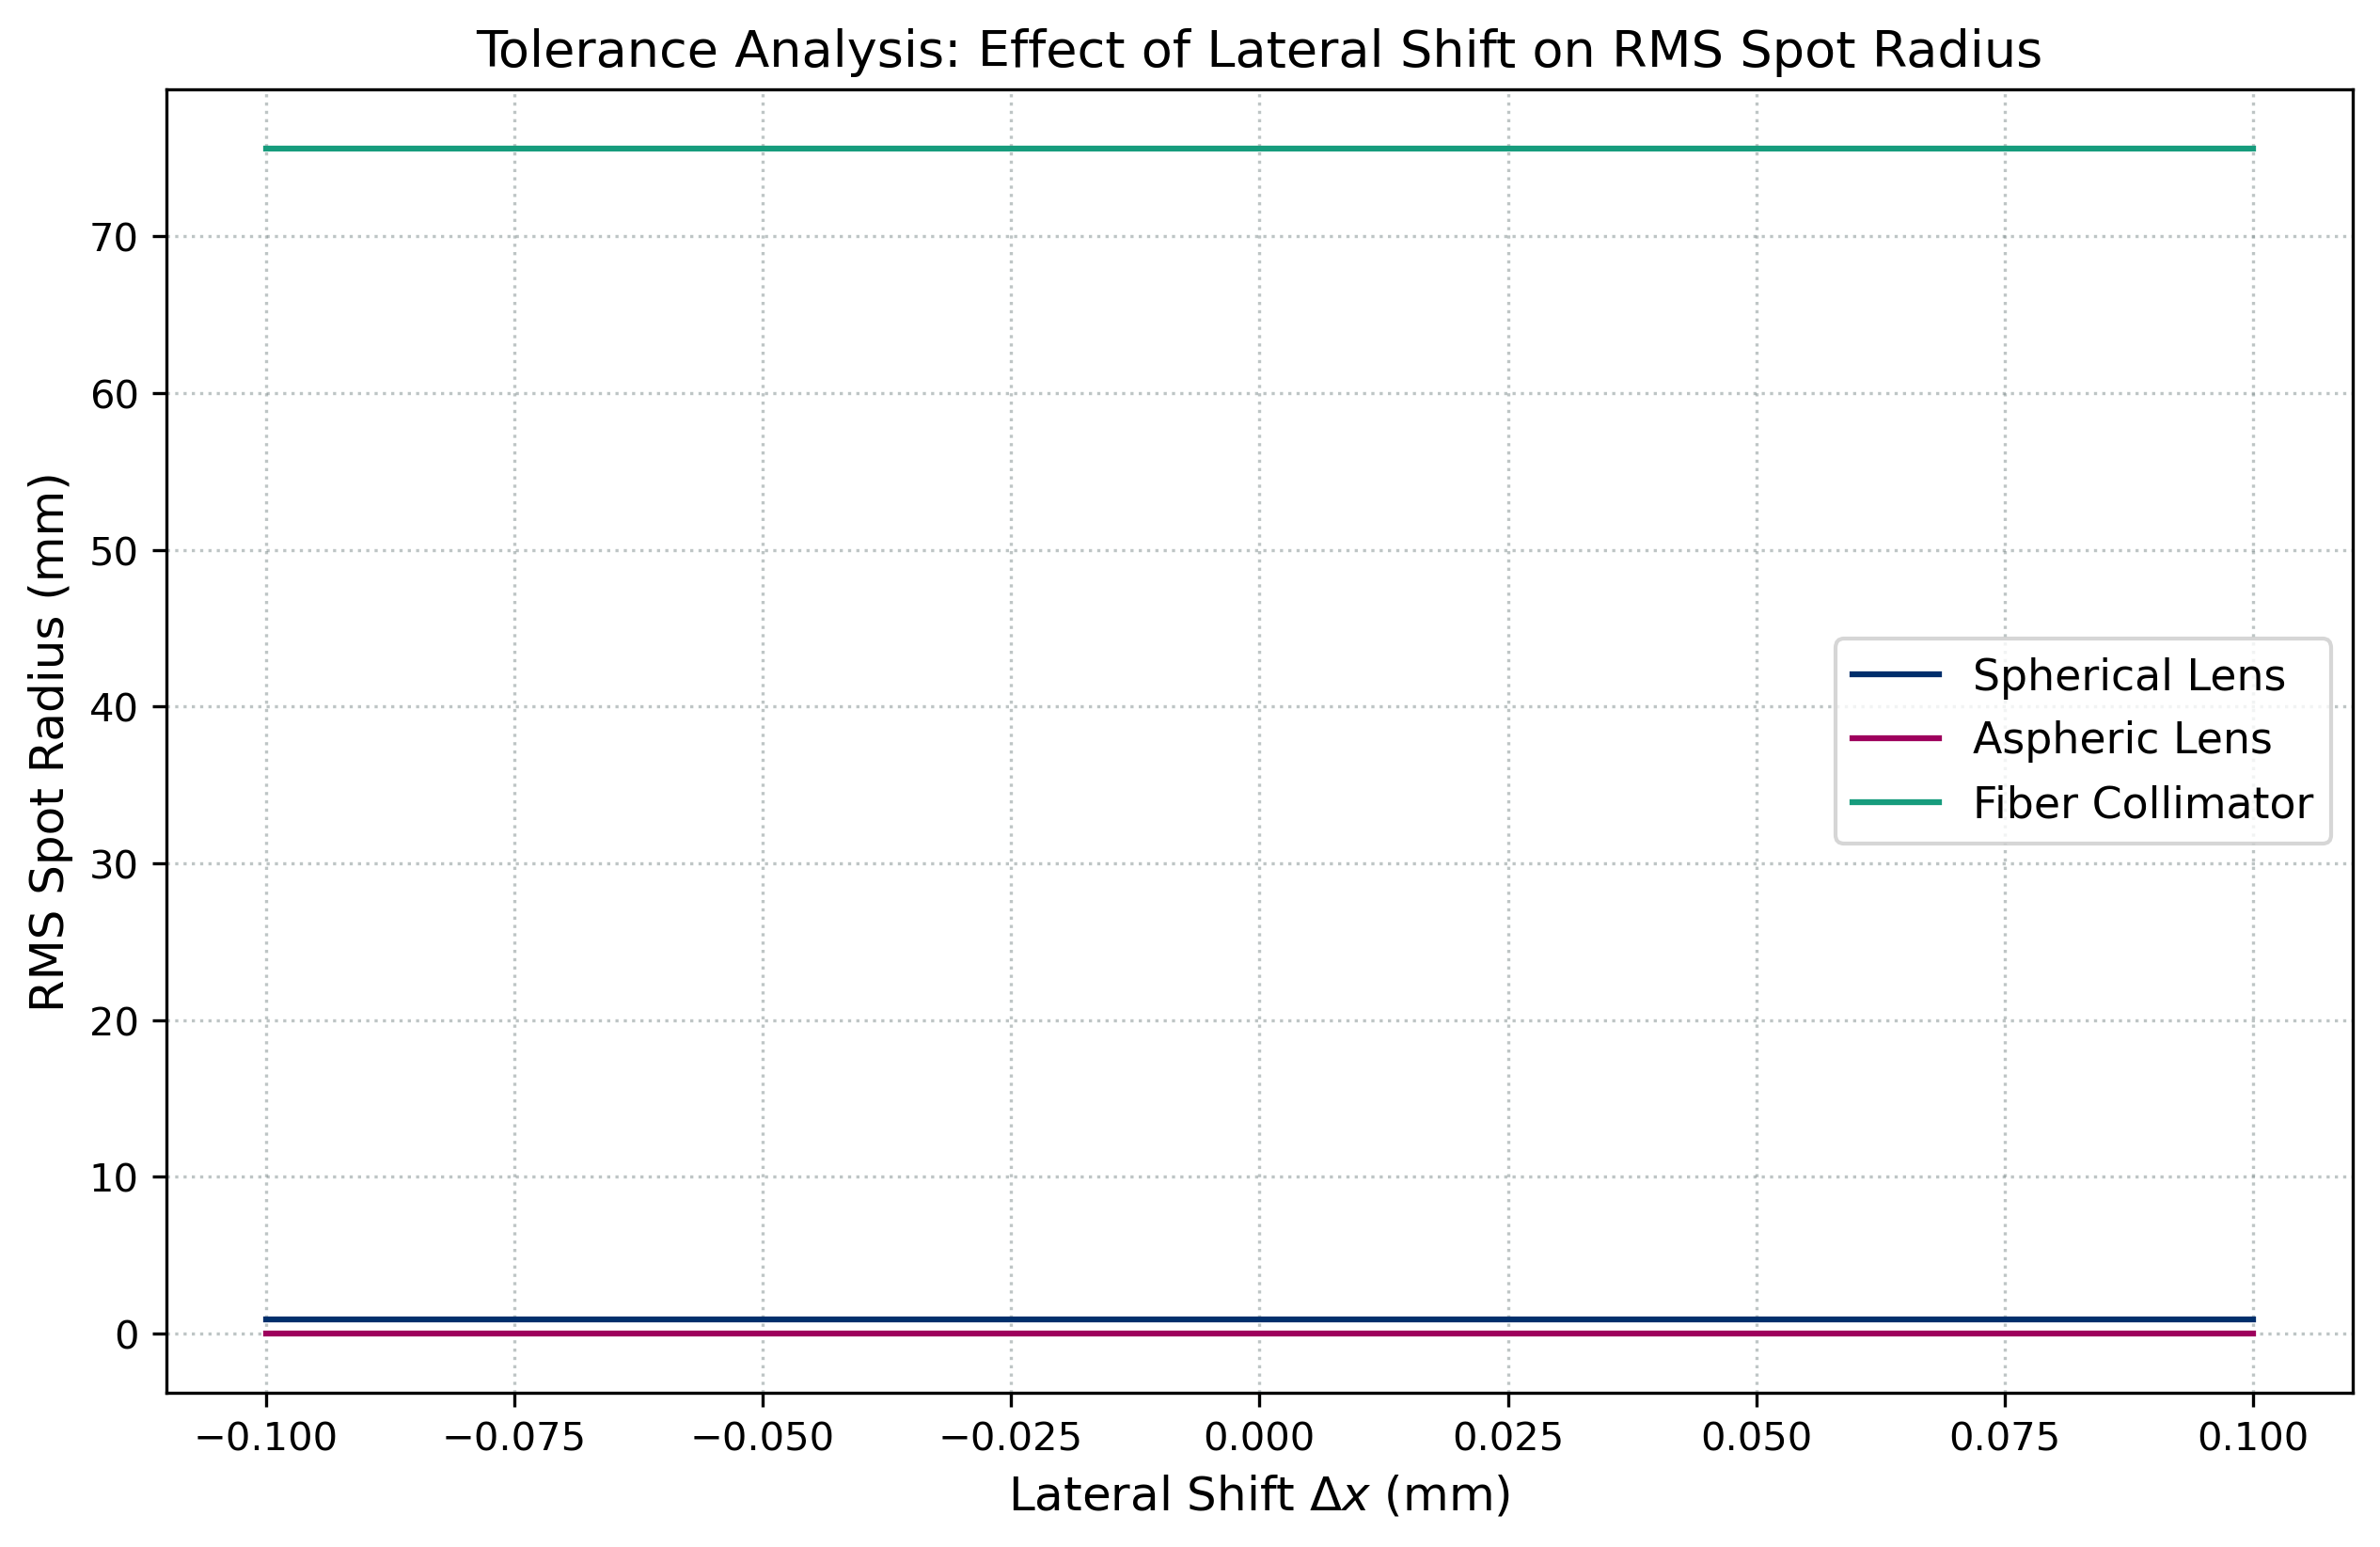

In [4]:
def simuliere_laterale_toleranz(url, dx_array):
    lens = load_zemax_file(url)
    rms_spot_radius = []
    
    wavelength_idx = 0
    field_idx = 0
    
    for x in dx_array:
        # Wir simulieren den lateralen Versatz (dx). 
        # Methode A: Der meist stabilere Weg in Python-APIs – wir verschieben den 
        # Startpunkt des Lichts (Field) auf der X-Achse um den Wert x:
        try:
            lens.fields.set_field(field_idx, x_value=x, y_value=0.0) 
        except AttributeError:
            # Methode B: Falls Optiland einen direkten Decenter-Befehl für den Updater hat:
            # (Wenn Methode A fehlschlägt, kommentiere A aus und nutze diese Zeile)
            # lens.updater.set_decenter_x(surface_number=1, value=x) 
            pass
        
        # Bild neu berechnen
        lens.image_solve()
        
        # Spot Radius berechnen und speichern
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius

# === 1. Simulation für laterales Spiel durchführen ===
# Laterales Spiel von -0.1 mm bis +0.1 mm
dx = np.linspace(-0.1, 0.1, 64)

print("Simulating lateral tolerance (Spherical Lens)...")
rms_lat_sphaere = simuliere_laterale_toleranz(url_sphaere, dx)

print("Simulating lateral tolerance (Aspheric Lens)...")
rms_lat_asphaere = simuliere_laterale_toleranz(url_asphaere, dx)

print("Simulating lateral tolerance (Fiber Collimator)...")
rms_lat_kolli = simuliere_laterale_toleranz(url_kolli, dx)

# === 2. Ergebnisse plotten ===
plt.figure(figsize=(10, 6))

# Plot der drei Kurven mit wissenschaftlichem Farbschema und englischer Legende
plt.plot(dx, rms_lat_sphaere, label="Spherical Lens", color="#002F6C")
plt.plot(dx, rms_lat_asphaere, label="Aspheric Lens", color="#9E005D")
plt.plot(dx, rms_lat_kolli, label="Fiber Collimator", color="#179C7D")

# Diagramm formatieren (Englisch)
plt.xlabel("Lateral Shift $\Delta x$ (mm)")
plt.ylabel("RMS Spot Radius (mm)")
plt.title("Tolerance Analysis: Effect of Lateral Shift on RMS Spot Radius") # Auskommentiert für sauberen Look im Paper
plt.legend()

# Plot als druckfähiges PDF speichern
plt.savefig(r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/ToleranceAnalysis_Lateral.pdf")

# Plot anzeigen
plt.show()